In [1]:
import torch
import torch.nn as nn

class BinaryClassifier(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2, hidden_layers=[256, 128, 64]):
        super().__init__()

        layerlist = []
        n_in = input_size

        for h in hidden_layers:
            layerlist += [
                nn.Linear(n_in, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate),
            ]
            n_in = h

        # Final output layer: 1 logit for binary classification
        layerlist.append(nn.Linear(n_in, 1))

        self.network = nn.Sequential(*layerlist)

        # Better initialization (same as before)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x):
        # shape: (batch_size, 1) → squeeze to (batch_size,)
        logits = self.network(x).squeeze(-1)
        return logits


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# 0) Load ALREADY-SCALED binary dataset
df_binary = pd.read_csv("artifacts/final_train_scaled_binary_clustered.csv")

TARGET_COL = "MP_binary_high"

# Exclude non-features
exclude = {"SMILES", TARGET_COL, "MW", "MP", "MP_category_default", "Structure_Cluster"}

# Use only numeric feature columns
num_cols = df_binary.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

# Build X/y
X = df_binary[feature_cols].to_numpy(np.float32)
y = df_binary[TARGET_COL].to_numpy(np.float32)

# Stratification labels (cluster)
y_strat = df_binary["Structure_Cluster"].astype(str).to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("n features:", len(feature_cols))
print("Label counts:", dict(zip(*np.unique(y, return_counts=True))))

# 1) Fix folds once
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds = [(tr_idx, val_idx) for tr_idx, val_idx in skf.split(X, y_strat)]
print("Built folds:", len(folds))


X shape: (17625, 202)
y shape: (17625,)
n features: 202
Label counts: {np.float32(0.0): np.int64(16853), np.float32(1.0): np.int64(772)}
Built folds: 10


In [ ]:
from sklearn.metrics import accuracy_score
from pathlib import Path

#Source: https://stackoverflow.com/questions/71998978/early-stopping-in-pytorch

# Early Stopping Based on Validation Loss
class EarlyStopper:

    # If the val loss has not been improved (i.e. stayed the same or got worse) for 20 epochs in a row, the training of the model is stopped.
    def __init__(self, patience=30, min_delta=0):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.counter = 0
        self.best_loss = float('inf')
        self.stop = False
        self.stop_epoch = None  # remember which epoch we stopped on (for plotting)

    def early_stop(self, val_loss, epoch=None):

        #For each epoch, checks if the validation loss has improved, we reset the counter.
        # We increase the counter if there is no improvement. Once the counter reaches the patience, we stop and remember the epoch.

        # Improvement means the loss decreased by more than min_delta
        if (self.best_loss - val_loss) > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            # No meaningful improvement this epoch
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                self.stop_epoch = epoch
        return self.stop
    

from scipy.special import expit  # stable sigmoid

def save_checkpoint(
    model,
    optimizer,
    epoch,
    train_loss,
    val_loss,
    y_train,
    y_val,
    val_loader,
    fold_idx,
    checkpoint_dir,
    checkpoint_tracking,
    is_final=False,
):
    # Put model in eval mode and collect logits
    model.eval()
    all_logits = []
    with torch.no_grad():
        for xb, _ in val_loader:
            logits = model(xb).cpu().numpy()
            all_logits.append(logits)

    logits_val = np.concatenate(all_logits)   # shape (N,)
    probs_val  = expit(logits_val)            # stable sigmoid
    preds_val  = (probs_val >= 0.5).astype(int)

    # y_val expected as numpy 0/1
    y_val_np = np.asarray(y_val).astype(int)

    # Classification metric: accuracy
    acc = accuracy_score(y_val_np, preds_val)

    # Filename
    if is_final:
        checkpoint_filename = f"checkpoint_epoch_{epoch:03d}_final.pt"
    else:
        checkpoint_filename = f"checkpoint_epoch_{epoch:03d}.pt"

    checkpoint_path_full = Path(checkpoint_dir) / checkpoint_filename

    # Save checkpoint (weights + optimizer + losses + metric)
    checkpoint_data = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": acc,
        "fold_idx": fold_idx,
        "is_final": is_final,
    }
    torch.save(checkpoint_data, checkpoint_path_full)

    # Track info for CSV
    checkpoint_info = {
        "Fold": fold_idx,
        "Epoch": epoch,
        "Checkpoint_Filename": checkpoint_filename,
        "Checkpoint_Path": str(checkpoint_path_full),
        "Train_Loss": round(train_loss, 6),
        "Val_Loss": round(val_loss, 6),
        "Accuracy": round(acc, 6),
        "Is_Final": is_final,
    }
    checkpoint_tracking.append(checkpoint_info)

    checkpoint_type = "Final" if is_final else "Regular"
    print(
        f"[Fold {fold_idx}] {checkpoint_type} checkpoint saved at epoch {epoch} - "
        f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f}"
    )
    return True

In [4]:
import copy
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score

# NEW: undersamplers
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, EditedNearestNeighbours


def evaluate_fold(
    trial,
    fold_idx,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    hidden_layers,
    learning_rate,
    batch_size,
    dropout_rate,
    weight_decay,
    max_epochs=10**9,
    patience=30,
    min_delta=0,
    save_checkpoints=True,
    checkpoint_dir="checkpoints_classifier",
    save_every_n_epochs=15,

    # ----------------------------
    # NEW: undersampling controls
    # ----------------------------
    use_undersample=True,
    undersample_method="random",     # "random" | "tomek" | "nearmiss" | "enn"
    undersample_kwargs=None,
):

    device = torch.device("cpu")
    print(f"Fold {fold_idx}: Training on cpu (binary classifier, BCELoss)")

    # ---- checkpoints ----
    checkpoint_tracking = []
    if save_checkpoints:
        checkpoint_path = Path(checkpoint_dir)
        checkpoint_path.mkdir(parents=True, exist_ok=True)
        fold_checkpoint_dir = checkpoint_path / f"fold_{fold_idx}"
        fold_checkpoint_dir.mkdir(parents=True, exist_ok=True)
        print(f"Checkpoint saved to: {fold_checkpoint_dir}")

    # ==========================================================
    # Apply UNDERSAMPLING on TRAIN ONLY (never on validation)
    # ==========================================================
    if use_undersample:
        undersample_kwargs = undersample_kwargs or {}

        method = (undersample_method or "random").lower()
        if method == "random":
            sampler = RandomUnderSampler(random_state=42, **undersample_kwargs)
        elif method == "tomek":
            # Note: TomekLinks is more of a "cleaning" undersampler.
            sampler = TomekLinks(**undersample_kwargs)
        elif method == "nearmiss":
            sampler = NearMiss(**undersample_kwargs)
        elif method == "enn":
            sampler = EditedNearestNeighbours(**undersample_kwargs)
        else:
            raise ValueError(
                f"Unknown undersample_method='{undersample_method}'. "
                "Use: 'random', 'tomek', 'nearmiss', or 'enn'."
            )

        # 1) imblearn expects integer labels (0/1)
        y_train_int = np.asarray(y_train).astype(np.int64)

        # 2) Resample majority DOWN
        X_train_scaled, y_train_int = sampler.fit_resample(X_train_scaled, y_train_int)

        # 3) Convert back to float for BCELoss
        y_train = y_train_int.astype(np.float32)

        print(
            f"[Fold {fold_idx}] After UNDERSAMPLING ({method}): "
            f"X_train={X_train_scaled.shape}, counts={np.bincount(y_train_int)}"
        )
    else:
        y_train = np.asarray(y_train).astype(np.float32)

    # ---- tensors (y must be float 0/1) ----
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_tensor   = torch.tensor(y_val, dtype=torch.float32).to(device)

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    # ---- model + BCELoss ----
    model = BinaryClassifier(
        input_size=X_train_scaled.shape[1],
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
    ).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

    early_stopper = EarlyStopper(patience=patience, min_delta=min_delta)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    train_losses, val_losses = [], []
    stop_epoch = None

    # ---- training loop ----
    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()

            logits = model(xb)  # (batch,)
            probs  = torch.sigmoid(logits).clamp(1e-6, 1 - 1e-6)
            loss   = criterion(probs, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # ---- validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                probs  = torch.sigmoid(logits).clamp(1e-6, 1 - 1e-6)
                loss   = criterion(probs, yb)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # track best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        # checkpoints
        if save_checkpoints and (epoch % save_every_n_epochs == 0 or epoch == 1):
            save_checkpoint(
                model, optimizer, epoch, train_loss, val_loss,
                y_train, y_val, val_loader,
                fold_idx, fold_checkpoint_dir, checkpoint_tracking,
                is_final=False
            )

        # early stopping
        if early_stopper.early_stop(val_loss, epoch=epoch):
            stop_epoch = early_stopper.stop_epoch
            print(f"[Fold {fold_idx}] Early stopping at epoch {stop_epoch} (best Val Loss: {best_val_loss:.4f})")

            if save_checkpoints and epoch % save_every_n_epochs != 0 and epoch != 1:
                save_checkpoint(
                    model, optimizer, epoch, train_loss, val_loss,
                    y_train, y_val, val_loader,
                    fold_idx, fold_checkpoint_dir, checkpoint_tracking,
                    is_final=True
                )
            break

        if epoch % 50 == 0 or epoch == 1:
            print(f"[Fold {fold_idx}] Epoch {epoch:4d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | ES {early_stopper.counter}/{patience}")

    # ---- load best ----
    model.load_state_dict(best_state)
    model.eval()

    # save checkpoint tracking csv
    if save_checkpoints and checkpoint_tracking:
        df_ckpt = pd.DataFrame(checkpoint_tracking)
        df_ckpt.to_csv(fold_checkpoint_dir / f"fold_{fold_idx}_checkpoints_classifier.csv", index=False)

    # ---- final accuracy on val set (best model) ----
    all_logits = []
    with torch.no_grad():
        for xb, _ in val_loader:
            all_logits.append(model(xb).cpu().numpy())
    logits_val = np.concatenate(all_logits)
    probs_val  = 1 / (1 + np.exp(-logits_val))
    preds_val  = (probs_val >= 0.5).astype(int)

    y_val_np = np.asarray(y_val).astype(int)
    acc = accuracy_score(y_val_np, preds_val)

    return best_val_loss, acc, model, train_losses, val_losses, stop_epoch


In [7]:
import time
import numpy as np
from pathlib import Path

trial_times = []

def objective(trial):
    # Suggest hyperparameters
    dropout_rate  = trial.suggest_float("dropout_rate",  0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay  = trial.suggest_float("weight_decay",  1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Hidden layers (same logic)
    h1 = trial.suggest_categorical("h1", [64, 96, 128, 160, 192, 224, 256])
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    hidden_layers = [h1, h2, h3]

    start = time.perf_counter()

    val_losses = []
    accs = []

    # Run this hyperparameter combo across all folds
    for fold_idx, (tr_idx, val_idx) in enumerate(folds):
        X_train_scaled = X[tr_idx]
        y_train        = y[tr_idx]
        X_val_scaled   = X[val_idx]
        y_val          = y[val_idx]

        # Put classifier checkpoints in a classifier-specific folder
        trial_checkpoint_root = Path("checkpoints_binary_classifier") / f"trial_{trial.number:03d}"

        best_val_loss, acc, _, _, _, _ = evaluate_fold(
            trial=trial,
            fold_idx=fold_idx,
            X_train_scaled=X_train_scaled,
            y_train=y_train,
            X_val_scaled=X_val_scaled,
            y_val=y_val,
            learning_rate=learning_rate,
            batch_size=batch_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
            weight_decay=weight_decay,
            save_checkpoints=False,
            checkpoint_dir=trial_checkpoint_root,
        )

        val_losses.append(best_val_loss)
        accs.append(acc)

    elapsed = (time.perf_counter() - start) / 60.0
    trial_times.append(elapsed)
    print(f"Trial {trial.number} finished in {elapsed:.2f} minutes")

    avg_val_loss = float(np.mean(val_losses))
    avg_acc      = float(np.mean(accs))

    print(f"Trial {trial.number}: Avg Val Loss = {avg_val_loss:.4f} | Avg Acc = {avg_acc:.4f}")

    # Optuna minimizes this
    return avg_val_loss

In [8]:
import optuna

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

best_params = study.best_params
print(best_params)

[I 2026-01-03 23:11:53,585] A new study created in memory with name: no-name-e940bcbf-311c-443c-a47e-3e47d40db48b


Fold 0: Training on cpu (binary classifier, BCELoss)
[Fold 0] After UNDERSAMPLING (random): X_train=(1390, 202), counts=[695 695]
[Fold 0] Epoch    1 | Train Loss: 0.8057 | Val Loss: 0.6031 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 0.4021 | Val Loss: 0.3352 | ES 2/30
[Fold 0] Epoch  100 | Train Loss: 0.3631 | Val Loss: 0.3666 | ES 11/30
[Fold 0] Early stopping at epoch 119 (best Val Loss: 0.2735)
Fold 1: Training on cpu (binary classifier, BCELoss)
[Fold 1] After UNDERSAMPLING (random): X_train=(1404, 202), counts=[702 702]
[Fold 1] Epoch    1 | Train Loss: 0.8162 | Val Loss: 0.7755 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 0.3563 | Val Loss: 0.3270 | ES 14/30
[Fold 1] Early stopping at epoch 82 (best Val Loss: 0.2943)
Fold 2: Training on cpu (binary classifier, BCELoss)
[Fold 2] After UNDERSAMPLING (random): X_train=(1388, 202), counts=[694 694]
[Fold 2] Epoch    1 | Train Loss: 0.9226 | Val Loss: 0.9040 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 0.3716 | Val Loss: 0.3513 | ES 3/

[I 2026-01-03 23:13:09,588] Trial 0 finished with value: 0.29922790919170456 and parameters: {'dropout_rate': 0.3923977238672135, 'learning_rate': 0.00021527008052995176, 'weight_decay': 3.211272652939757e-06, 'batch_size': 16, 'h1': 96}. Best is trial 0 with value: 0.29922790919170456.


[Fold 9] Early stopping at epoch 90 (best Val Loss: 0.2641)
Trial 0 finished in 1.27 minutes
Trial 0: Avg Val Loss = 0.2992 | Avg Acc = 0.8646
Fold 0: Training on cpu (binary classifier, BCELoss)
[Fold 0] After UNDERSAMPLING (random): X_train=(1390, 202), counts=[695 695]
[Fold 0] Epoch    1 | Train Loss: 0.7801 | Val Loss: 1.0196 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 0.1936 | Val Loss: 0.3612 | ES 15/30
[Fold 0] Early stopping at epoch 65 (best Val Loss: 0.3198)
Fold 1: Training on cpu (binary classifier, BCELoss)
[Fold 1] After UNDERSAMPLING (random): X_train=(1404, 202), counts=[702 702]
[Fold 1] Epoch    1 | Train Loss: 0.7027 | Val Loss: 0.7080 | ES 0/30
[Fold 1] Early stopping at epoch 46 (best Val Loss: 0.3530)
Fold 2: Training on cpu (binary classifier, BCELoss)
[Fold 2] After UNDERSAMPLING (random): X_train=(1388, 202), counts=[694 694]
[Fold 2] Epoch    1 | Train Loss: 0.7415 | Val Loss: 0.6223 | ES 0/30
[Fold 2] Early stopping at epoch 48 (best Val Loss: 0.3740)
Fold 3

[I 2026-01-03 23:13:51,346] Trial 1 finished with value: 0.3444591580757074 and parameters: {'dropout_rate': 0.2671782411805589, 'learning_rate': 0.00048736947813309266, 'weight_decay': 4.5553782453975977e-05, 'batch_size': 64, 'h1': 160}. Best is trial 0 with value: 0.29922790919170456.


...

[Fold 9] Early stopping at epoch 57 (best Val Loss: 0.3054)
Trial 17 finished in 1.18 minutes
Trial 17: Avg Val Loss = 0.2885 | Avg Acc = 0.8722
Fold 0: Training on cpu (binary classifier, BCELoss)
[Fold 0] After UNDERSAMPLING (random): X_train=(1390, 202), counts=[695 695]
[Fold 0] Epoch    1 | Train Loss: 0.8549 | Val Loss: 0.8413 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 0.4824 | Val Loss: 0.3370 | ES 2/30
[Fold 0] Epoch  100 | Train Loss: 0.4013 | Val Loss: 0.2706 | ES 0/30
[Fold 0] Early stopping at epoch 130 (best Val Loss: 0.2706)
Fold 1: Training on cpu (binary classifier, BCELoss)
[Fold 1] After UNDERSAMPLING (random): X_train=(1404, 202), counts=[702 702]
[Fold 1] Epoch    1 | Train Loss: 0.8107 | Val Loss: 0.5567 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 0.4599 | Val Loss: 0.4093 | ES 5/30
[Fold 1] Epoch  100 | Train Loss: 0.4045 | Val Loss: 0.3814 | ES 8/30
[Fold 1] Early stopping at epoch 141 (best Val Loss: 0.3513)
Fold 2: Training on cpu (binary classifier, BCELoss)


[I 2026-01-03 23:37:02,630] Trial 18 finished with value: 0.3530916854872236 and parameters: {'dropout_rate': 0.32702083248932834, 'learning_rate': 5.155152464008468e-05, 'weight_decay': 0.00017783553961719096, 'batch_size': 32, 'h1': 160}. Best is trial 15 with value: 0.28085605869791264.


[Fold 9] Early stopping at epoch 41 (best Val Loss: 0.4322)
Trial 18 finished in 1.11 minutes
Trial 18: Avg Val Loss = 0.3531 | Avg Acc = 0.8407
Fold 0: Training on cpu (binary classifier, BCELoss)
[Fold 0] After UNDERSAMPLING (random): X_train=(1390, 202), counts=[695 695]
[Fold 0] Epoch    1 | Train Loss: 0.7518 | Val Loss: 0.7897 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 0.3766 | Val Loss: 0.3482 | ES 7/30
[Fold 0] Epoch  100 | Train Loss: 0.3407 | Val Loss: 0.3298 | ES 22/30
[Fold 0] Early stopping at epoch 133 (best Val Loss: 0.3037)
Fold 1: Training on cpu (binary classifier, BCELoss)
[Fold 1] After UNDERSAMPLING (random): X_train=(1404, 202), counts=[702 702]
[Fold 1] Epoch    1 | Train Loss: 0.8288 | Val Loss: 0.6430 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 0.3585 | Val Loss: 0.4142 | ES 21/30
[Fold 1] Epoch  100 | Train Loss: 0.3132 | Val Loss: 0.3931 | ES 27/30
[Fold 1] Early stopping at epoch 103 (best Val Loss: 0.3822)
Fold 2: Training on cpu (binary classifier, BCELos

[I 2026-01-03 23:38:19,934] Trial 19 finished with value: 0.3441863987594843 and parameters: {'dropout_rate': 0.315184095324284, 'learning_rate': 0.00013760441019527265, 'weight_decay': 0.00016203806504199472, 'batch_size': 64, 'h1': 160}. Best is trial 15 with value: 0.28085605869791264.


[Fold 9] Early stopping at epoch 96 (best Val Loss: 0.3180)
Trial 19 finished in 1.29 minutes
Trial 19: Avg Val Loss = 0.3442 | Avg Acc = 0.8385
{'dropout_rate': 0.41259680698872414, 'learning_rate': 0.00014500833564350221, 'weight_decay': 1.3377249208752791e-05, 'batch_size': 16, 'h1': 160}


In [9]:
print("Best Trial Number:", study.best_trial.number)
print(best_params)

Best Trial Number: 15
{'dropout_rate': 0.41259680698872414, 'learning_rate': 0.00014500833564350221, 'weight_decay': 1.3377249208752791e-05, 'batch_size': 16, 'h1': 160}


In [10]:
from pathlib import Path
import torch
import pandas as pd

# BASE and artifacts_dir should already be defined (same script as before)
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"

# ---------- Directories for final best models + checkpoints ----------
best_models_dir = artifacts_dir / "binary_undersampling_best_models"
best_models_dir.mkdir(parents=True, exist_ok=True)

final_ckpt_dir = BASE / "checkpoints_binary_undersampling_best"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

print("Best hyperparameters from Optuna:", best_params)

# Helper to derive hidden layers from best_params (same logic as in objective)
def build_hidden_layers_from_best(best_params):
    h1 = best_params["h1"]
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    return [h1, h2, h3]

hidden_layers = build_hidden_layers_from_best(best_params)
dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("Using hidden_layers:", hidden_layers)
print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

final_fold_metrics = []

# ---------- Final training loop for all folds (using `folds`, X, y) ----------
# Assumes you already defined:
#   X, y, folds = [(tr_idx, val_idx), ...] earlier (same as in `objective`)
for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n==================== Final training for fold {fold_idx} ====================")

    X_train_scaled = X[tr_idx]
    y_train        = y[tr_idx]
    X_val_scaled   = X[val_idx]
    y_val          = y[val_idx]

    # Train this fold with the best hyperparameters
    best_val_loss, acc, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,
        fold_idx=fold_idx,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=hidden_layers,
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,
        checkpoint_dir=final_ckpt_dir,   # evaluate_fold will make fold_{k}/ inside
        save_every_n_epochs=15,
    )

    # ---------- Save the final (best) model for this fold ----------
    model_path = best_models_dir / f"binary_undersampling_best_fold_{fold_idx}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "hidden_layers": hidden_layers,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold_idx,
            "best_val_bce": float(best_val_loss),
            "val_accuracy": float(acc),
        },
        model_path,
    )
    print(f"[Fold {fold_idx}] Saved best classifier model to: {model_path}")
    print(f"[Fold {fold_idx}] Val BCE: {best_val_loss:.4f} | Val Acc: {acc:.4f} | Stop epoch: {stop_epoch}")

    # store metrics
    final_fold_metrics.append(
        {
            "Fold": fold_idx,
            "Best_Val_BCE": float(best_val_loss),
            "Val_Accuracy": float(acc),
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "classifier_undersampling_best_models_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n✅ Saved summary of best classifier undersampling models across folds to:", metrics_path)
print(metrics_df)


Best hyperparameters from Optuna: {'dropout_rate': 0.41259680698872414, 'learning_rate': 0.00014500833564350221, 'weight_decay': 1.3377249208752791e-05, 'batch_size': 16, 'h1': 160}
Using hidden_layers: [160, 80, 40]
dropout: 0.41259680698872414 | lr: 0.00014500833564350221 | wd: 1.3377249208752791e-05 | batch_size: 16

==================== Final training for fold 0 ====================
Fold 0: Training on cpu (binary classifier, BCELoss)
Checkpoint saved to: /Users/sdl5_mp/Documents/SDL5_MP/transfer_learning/checkpoints_binary_undersampling_best/fold_0
[Fold 0] After UNDERSAMPLING (random): X_train=(1390, 202), counts=[695 695]
[Fold 0] Regular checkpoint saved at epoch 1 - Val Loss: 0.4131 | Acc: 0.8826
[Fold 0] Epoch    1 | Train Loss: 0.8616 | Val Loss: 0.4131 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - Val Loss: 0.3723 | Acc: 0.8151
[Fold 0] Regular checkpoint saved at epoch 30 - Val Loss: 0.3742 | Acc: 0.8151
[Fold 0] Regular checkpoint saved at epoch 45 - Val Loss:

In [12]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix
from scipy.special import expit

confusion_matrices = []

for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n===== Confusion matrix for fold {fold_idx} =====")

    # Load validation data
    X_val = X[val_idx]
    y_val = y[val_idx].astype(int)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

    # Load best model
    model_path = best_models_dir / f"binary_undersampling_best_fold_{fold_idx}.pt"
    checkpoint = torch.load(model_path, map_location="cpu")

    model = BinaryClassifier(
        input_size=X.shape[1],
        hidden_layers=checkpoint["hidden_layers"],
        dropout_rate=checkpoint["dropout_rate"],
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # Predict
    with torch.no_grad():
        logits = model(X_val_tensor).cpu().numpy()

    probs = expit(logits)
    preds = (probs >= 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_val, preds, labels=[0, 1])
    confusion_matrices.append(cm)

    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

    tn, fp, fn, tp = cm.ravel()
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")




===== Confusion matrix for fold 0 =====
Confusion matrix (rows=true, cols=pred):
[[1456  230]
 [  18   59]]
TN=1456, FP=230, FN=18, TP=59

===== Confusion matrix for fold 1 =====
Confusion matrix (rows=true, cols=pred):
[[1476  217]
 [  14   56]]
TN=1476, FP=217, FN=14, TP=56

===== Confusion matrix for fold 2 =====
Confusion matrix (rows=true, cols=pred):
[[1456  229]
 [  15   63]]
TN=1456, FP=229, FN=15, TP=63

===== Confusion matrix for fold 3 =====
Confusion matrix (rows=true, cols=pred):
[[1506  195]
 [  16   46]]
TN=1506, FP=195, FN=16, TP=46

===== Confusion matrix for fold 4 =====
Confusion matrix (rows=true, cols=pred):
[[1455  219]
 [  13   76]]
TN=1455, FP=219, FN=13, TP=76

===== Confusion matrix for fold 5 =====
Confusion matrix (rows=true, cols=pred):
[[1505  182]
 [  23   52]]
TN=1505, FP=182, FN=23, TP=52

===== Confusion matrix for fold 6 =====
Confusion matrix (rows=true, cols=pred):
[[1405  256]
 [  16   85]]
TN=1405, FP=256, FN=16, TP=85

===== Confusion matrix for

/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_84628/4118354100.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_loca

In [13]:
mean_cm = np.mean(confusion_matrices, axis=0)

mean_cm_df = pd.DataFrame(
    mean_cm,
    index=["True Low&Int", "True High"],
    columns=["Pred Low&Int", "Pred High"],
)

print("\n===== Mean confusion matrix across folds =====")
print(mean_cm_df)

# Save to CSV
mean_cm_path = best_models_dir / "binary_mean_confusion_matrix.csv"
mean_cm_df.to_csv(mean_cm_path)
print(f"\n✅ Saved mean confusion matrix to: {mean_cm_path}")



===== Mean confusion matrix across folds =====
              Pred Low&Int  Pred High
True Low&Int        1468.7      216.6
True High             17.1       60.1

✅ Saved mean confusion matrix to: /Users/sdl5_mp/Documents/SDL5_MP/transfer_learning/artifacts/binary_undersampling_best_models/binary_mean_confusion_matrix.csv


In [14]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix
from scipy.special import expit  # stable sigmoid

def metrics_from_confusion(cm):
    """
    cm = [[TN, FP],
          [FN, TP]]
    """
    TN, FP, FN, TP = cm.ravel()

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
    }

all_fold_metrics = []
all_conf_matrices = []

for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\nEvaluating fold {fold_idx}")

    # Load best model for this fold
    ckpt = torch.load(best_models_dir / f"binary_undersampling_best_fold_{fold_idx}.pt", map_location="cpu")

    model = BinaryClassifier(
        input_size=X.shape[1],
        hidden_layers=ckpt["hidden_layers"],
        dropout_rate=ckpt["dropout_rate"],
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    # Validation data
    X_val = torch.tensor(X[val_idx], dtype=torch.float32)
    y_val = y[val_idx].astype(int)

    # Predict
    with torch.no_grad():
        logits = model(X_val).numpy()

    probs = expit(logits)
    preds = (probs >= 0.5).astype(int)

    # Confusion matrix: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_val, preds)
    all_conf_matrices.append(cm)

    # Metrics
    metrics = metrics_from_confusion(cm)
    metrics["Fold"] = fold_idx
    all_fold_metrics.append(metrics)

    print("Confusion matrix:\n", cm)
    print(metrics)



Evaluating fold 0
Confusion matrix:
 [[1456  230]
 [  18   59]]
{'Accuracy': np.float64(0.8593306863301191), 'Precision': np.float64(0.2041522491349481), 'Recall': np.float64(0.7662337662337663), 'F1': np.float64(0.3224043715846994), 'Specificity': np.float64(0.863582443653618), 'Fold': 0}

Evaluating fold 1
Confusion matrix:
 [[1476  217]
 [  14   56]]
{'Accuracy': np.float64(0.8689733408961997), 'Precision': np.float64(0.20512820512820512), 'Recall': np.float64(0.8), 'F1': np.float64(0.326530612244898), 'Specificity': np.float64(0.8718251624335499), 'Fold': 1}

Evaluating fold 2
Confusion matrix:
 [[1456  229]
 [  15   63]]
{'Accuracy': np.float64(0.8615995462280204), 'Precision': np.float64(0.21575342465753425), 'Recall': np.float64(0.8076923076923077), 'F1': np.float64(0.3405405405405405), 'Specificity': np.float64(0.8640949554896142), 'Fold': 2}

Evaluating fold 3
Confusion matrix:
 [[1506  195]
 [  16   46]]
{'Accuracy': np.float64(0.8803176403857061), 'Precision': np.float64(0.

/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_84628/1652211935.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_models_dir / f"binary

In [15]:
metrics_df = pd.DataFrame(all_fold_metrics)

mean_metrics = metrics_df.mean(numeric_only=True)
std_metrics  = metrics_df.std(numeric_only=True)

summary_df = pd.DataFrame({
    "Mean": mean_metrics,
    "Std": std_metrics
})

print("\n=== Cross-validated performance ===")
print(summary_df)

summary_df.to_csv(
    best_models_dir / "binary_undersampling_classifier_confusion_metrics_summary.csv"
)



=== Cross-validated performance ===
                 Mean       Std
Accuracy     0.867404  0.012154
Precision    0.216291  0.027433
Recall       0.773860  0.051354
F1           0.337526  0.036795
Specificity  0.871433  0.014021
Fold         4.500000  3.027650


In [18]:
##-------------------------------- FOR THE MISCLASSIFIED SAMPLES-----------------------------------------------##

import numpy as np
import pandas as pd
import torch
from pathlib import Path

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from scipy.special import expit  # stable sigmoid

# ------------------------------------------------------------
# REQUIRED: you must already have these defined in your session:
#   - X (numpy array, shape [N, D])
#   - y (numpy array, shape [N,])
#   - folds = [(tr_idx, val_idx), ...]
#   - best_models_dir (Path where binary_best_fold_{k}.pt are saved)
#   - BinaryClassifier class definition (same as training)
# ------------------------------------------------------------

out_dir = Path("artifacts")
out_dir.mkdir(parents=True, exist_ok=True)

probs_csv_path   = out_dir / "classifier_undersampling_val_probabilities_all_folds.csv"
cms_csv_path     = out_dir / "classifier_undersampling_confusion_matrices_all_folds.csv"
miscls_csv_path  = out_dir / "classifier_undersampling_val_misclassified_only.csv"

all_rows = []          # per-sample probabilities (all)
mis_rows = []          # misclassified only
confusion_rows = []    # per-fold confusion matrix + metrics

device = torch.device("cpu")

for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n===== Fold {fold_idx} =====")

    # Validation data
    X_val = X[val_idx]
    y_val = y[val_idx].astype(int)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32, device=device)

    # Load best model checkpoint for this fold
    model_path = Path(best_models_dir) / f"binary_undersampling_best_fold_{fold_idx}.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"Missing model file: {model_path}")

    checkpoint = torch.load(model_path, map_location="cpu")

    model = BinaryClassifier(
        input_size=X.shape[1],
        hidden_layers=checkpoint["hidden_layers"],
        dropout_rate=checkpoint["dropout_rate"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # Predict logits -> probabilities
    with torch.no_grad():
        logits = model(X_val_tensor).detach().cpu().numpy()

    probs = expit(logits).reshape(-1)   # P(class=1) = P(High)
    preds = (probs >= 0.5).astype(int)

    # Confusion matrix + metrics
    cm = confusion_matrix(y_val, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc  = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val, preds, zero_division=0)
    f1   = f1_score(y_val, preds, zero_division=0)

    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"Acc={acc:.4f} | Prec={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")

    confusion_rows.append(
        {
            "fold": fold_idx,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "n_val": int(len(y_val)),
            "model_path": str(model_path),
        }
    )

    # Build per-sample rows (and misclassified subset)
    mis_mask = preds != y_val

    for i, original_idx in enumerate(val_idx):
        row = {
            "fold": fold_idx,
            "original_index": int(original_idx),   # index into your full X/y
            "true_label": int(y_val[i]),
            "pred_label": int(preds[i]),
            "logit": float(logits[i]),
            "prob_high": float(probs[i]),
            "prob_low": float(1.0 - probs[i]),
            "is_misclassified": bool(mis_mask[i]),
            # Useful error-type tag:
            # FP: true=0 pred=1, FN: true=1 pred=0
            "error_type": (
                "FP" if (y_val[i] == 0 and preds[i] == 1)
                else ("FN" if (y_val[i] == 1 and preds[i] == 0) else "")
            ),
        }

        all_rows.append(row)
        if mis_mask[i]:
            mis_rows.append(row)

# ------------------------------------------------------------
# Write outputs
# ------------------------------------------------------------
probs_df = pd.DataFrame(all_rows).sort_values(["fold", "original_index"]).reset_index(drop=True)
probs_df.to_csv(probs_csv_path, index=False)

cms_df = pd.DataFrame(confusion_rows).sort_values("fold").reset_index(drop=True)
cms_df.to_csv(cms_csv_path, index=False)

mis_df = pd.DataFrame(mis_rows).sort_values(["fold", "error_type", "prob_high"], ascending=[True, True, False]).reset_index(drop=True)
mis_df.to_csv(miscls_csv_path, index=False)

print("\n✅ Saved per-sample validation probabilities to:", probs_csv_path)
print("✅ Saved per-fold confusion matrices + metrics to:", cms_csv_path)
print("✅ Saved MISCLASSIFIED-only validation rows to:", miscls_csv_path)

# Optional: show quick summary counts
if len(mis_df) > 0:
    print("\nMisclassified counts by type:")
    print(mis_df["error_type"].value_counts(dropna=False))
else:
    print("\nNo misclassifications found (mis_df is empty).")



===== Fold 0 =====
Confusion matrix (rows=true, cols=pred):
[[1456  230]
 [  18   59]]
TN=1456, FP=230, FN=18, TP=59
Acc=0.8593 | Prec=0.2042 | Recall=0.7662 | F1=0.3224

===== Fold 1 =====
Confusion matrix (rows=true, cols=pred):
[[1476  217]
 [  14   56]]
TN=1476, FP=217, FN=14, TP=56
Acc=0.8690 | Prec=0.2051 | Recall=0.8000 | F1=0.3265

===== Fold 2 =====
Confusion matrix (rows=true, cols=pred):
[[1456  229]
 [  15   63]]
TN=1456, FP=229, FN=15, TP=63
Acc=0.8616 | Prec=0.2158 | Recall=0.8077 | F1=0.3405

===== Fold 3 =====
Confusion matrix (rows=true, cols=pred):
[[1506  195]
 [  16   46]]
TN=1506, FP=195, FN=16, TP=46
Acc=0.8803 | Prec=0.1909 | Recall=0.7419 | F1=0.3036

===== Fold 4 =====
Confusion matrix (rows=true, cols=pred):
[[1455  219]
 [  13   76]]
TN=1455, FP=219, FN=13, TP=76
Acc=0.8684 | Prec=0.2576 | Recall=0.8539 | F1=0.3958

===== Fold 5 =====
Confusion matrix (rows=true, cols=pred):
[[1505  182]
 [  23   52]]
TN=1505, FP=182, FN=23, TP=52
Acc=0.8837 | Prec=0.2222 | 

/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_84628/735607137.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_locat


✅ Saved per-sample validation probabilities to: artifacts/classifier_undersampling_val_probabilities_all_folds.csv
✅ Saved per-fold confusion matrices + metrics to: artifacts/classifier_undersampling_confusion_matrices_all_folds.csv
✅ Saved MISCLASSIFIED-only validation rows to: artifacts/classifier_undersampling_val_misclassified_only.csv

Misclassified counts by type:
error_type
FP    2166
FN     171
Name: count, dtype: int64


In [20]:
df = pd.read_csv("artifacts/classifier_undersampling_val_misclassified_only.csv")

fp = df[df["error_type"] == "FP"]  # Low → predicted High
fn = df[df["error_type"] == "FN"]  # High → predicted Low

In [27]:
fp["prob_high"].describe()
# Low MP predicted High

count    2166.000000
mean        0.710450
std         0.138816
min         0.500092
25%         0.588360
50%         0.697006
75%         0.820815
max         0.999997
Name: prob_high, dtype: float64

In [30]:
fn["prob_high"].describe()
# High MP predicted Low

count    171.000000
mean       0.285676
std        0.144423
min        0.006101
25%        0.165928
50%        0.293133
75%        0.422437
max        0.496622
Name: prob_high, dtype: float64

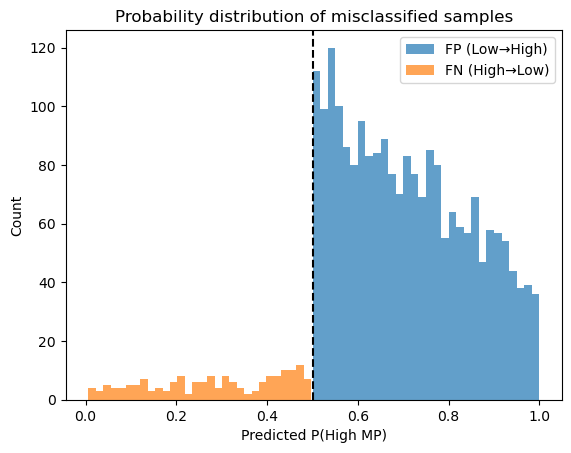

In [31]:
import matplotlib.pyplot as plt

plt.hist(fp["prob_high"], bins=30, alpha=0.7, label="FP (Low→High)")
plt.hist(fn["prob_high"], bins=30, alpha=0.7, label="FN (High→Low)")
plt.axvline(0.5, color="k", linestyle="--")
plt.xlabel("Predicted P(High MP)")
plt.ylabel("Count")
plt.legend()
plt.title("Probability distribution of misclassified samples")
plt.show()
